# Capítol I — Preprocés i Construcció de Variables RFM

**TFG — Grau d'Estadística UB-UPC**  
Segmentació de clients i predicció de churn en el sector retail: una aplicació al dataset d'H&M Group

Aquest notebook implementa el preprocés del dataset H&M Personalized Fashion Recommendations i construeix les variables RFM (Recency, Frequency, Monetary). Genera les figures 1.1-1.4 i les taules 1.1-1.3 del Capítol I.

**Inputs**: `data/customers.csv`, `data/articles.csv`, `data/transactions_train.csv`  
**Outputs**: `outputs/rfm_clients.csv`, `outputs/rfm_clients.parquet`, figures PNG

In [34]:
# Importacions: les eines que farem servir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració dels gràfics (per a què surtin bonics al TFG)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Llibreries importades correctament ✓")

Llibreries importades correctament ✓


In [35]:
# Llegim el fitxer customers.csv
customers = pd.read_csv("../data/customers.csv")

# Quantes files i columnes té?
print("Forma del DataFrame:", customers.shape)

Forma del DataFrame: (1371980, 7)


In [36]:
# Ensenya'm les 5 primeres files
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [37]:
# Tipus de dades de cada columna
customers.dtypes

customer_id                   str
FN                        float64
Active                    float64
club_member_status            str
fashion_news_frequency        str
age                       float64
postal_code                   str
dtype: object

In [38]:
# Quants valors absents té cada columna?
customers.isna().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [39]:
# Percentatge de valors absents per columna
percentatge_nan = (customers.isna().sum() / len(customers)) * 100
percentatge_nan.round(2)

customer_id                0.00
FN                        65.24
Active                    66.15
club_member_status         0.44
fashion_news_frequency     1.17
age                        1.16
postal_code                0.00
dtype: float64

In [40]:
# Llegim el catàleg d'articles
articles = pd.read_csv("../data/articles.csv")

# Forma del DataFrame
print("Forma:", articles.shape)

# Primeres files
articles.head()

Forma: (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [41]:
# Tipus de dades
print("=== TIPUS ===")
print(articles.dtypes)

# Valors absents (només mostrem les columnes amb NaN)
print("\n=== VALORS ABSENTS (només columnes amb NaN) ===")
nans = articles.isna().sum()
print(nans[nans > 0])

=== TIPUS ===
article_id                      int64
product_code                    int64
prod_name                         str
product_type_no                 int64
product_type_name                 str
product_group_name                str
graphical_appearance_no         int64
graphical_appearance_name         str
colour_group_code               int64
colour_group_name                 str
perceived_colour_value_id       int64
perceived_colour_value_name       str
perceived_colour_master_id      int64
perceived_colour_master_name      str
department_no                   int64
department_name                   str
index_code                        str
index_name                        str
index_group_no                  int64
index_group_name                  str
section_no                      int64
section_name                      str
garment_group_no                int64
garment_group_name                str
detail_desc                       str
dtype: object

=== VALORS ABSENTS (n

In [42]:
# Quants tipus de producte diferents hi ha?
print("Tipus de producte únics:", articles["product_type_name"].nunique())

# Top 10 més freqüents
print("\nTop 10 tipus de producte amb més articles al catàleg:")
articles["product_type_name"].value_counts().head(10)

Tipus de producte únics: 131

Top 10 tipus de producte amb més articles al catàleg:


product_type_name
Trousers    11169
Dress       10362
Sweater      9302
T-shirt      7904
Top          4155
Blouse       3979
Jacket       3940
Shorts       3939
Shirt        3405
Vest top     2991
Name: count, dtype: int64

In [43]:
print("Llegint transactions_train.csv... ")

# Càrrega senzilla. Només indiquem que t_dat és una data.
transactions = pd.read_csv(
    "../data/transactions_train.csv",
    parse_dates=["t_dat"],
)

print("✓ Càrrega completada")
print("Forma:", transactions.shape)

Llegint transactions_train.csv... 


✓ Càrrega completada
Forma: (31788324, 5)


In [44]:
# Primeres 5 files
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [45]:
# Quin període cobreixen les dades?
print("Primera data:", transactions["t_dat"].min().date())
print("Última data:", transactions["t_dat"].max().date())
print("Durada:", (transactions["t_dat"].max() - transactions["t_dat"].min()).days, "dies")

# Tipus de cada columna
print("\nTipus de dades:")
print(transactions.dtypes)

# Memòria ocupada
print("\nMemòria total:", round(transactions.memory_usage(deep=True).sum() / 1e9, 2), "GB")

Primera data: 2018-09-20
Última data: 2020-09-22
Durada: 733 dies

Tipus de dades:
t_dat               datetime64[us]
customer_id                    str
article_id                   int64
price                      float64
sales_channel_id             int64
dtype: object

Memòria total: 3.31 GB


In [46]:
# Valors absents a transactions
print("Valors absents per columna:")
print(transactions.isna().sum())

# Hi ha duplicats?
print("\nFiles duplicades:", transactions.duplicated().sum())

Valors absents per columna:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Files duplicades: 2974905


In [47]:
# Trobem la data més recent del dataset
data_max = transactions["t_dat"].max()

# Calculem la data d'inici de la finestra (1 any abans)
data_min_finestra = data_max - pd.DateOffset(years=1)

print(f"Finestra temporal escollida:")
print(f"  Inici:  {data_min_finestra.date()}")
print(f"  Final:  {data_max.date()}")

Finestra temporal escollida:
  Inici:  2019-09-22
  Final:  2020-09-22


In [48]:
# Apliquem el filtre temporal
tx = transactions[transactions["t_dat"] > data_min_finestra].copy()

print(f"Transaccions abans del filtre: {len(transactions):,}")
print(f"Transaccions després del filtre: {len(tx):,}")
print(f"Conservem el {len(tx) / len(transactions) * 100:.1f}% del total")

Transaccions abans del filtre: 31,788,324
Transaccions després del filtre: 14,898,423
Conservem el 46.9% del total


In [49]:
# Hi ha preus iguals o inferiors a 0?
print("Preu mínim:", tx["price"].min())
print("Preu màxim:", tx["price"].max())
print("Transaccions amb preu ≤ 0:", (tx["price"] <= 0).sum())

Preu mínim: 1.694915254237288e-05
Preu màxim: 0.5067796610169492
Transaccions amb preu ≤ 0: 0


In [50]:
# Definim la data de tall (T_snap)
T_SNAP = tx["t_dat"].max() + pd.Timedelta(days=1)

print(f"Data de tall (T_snap): {T_SNAP.date()}")
print(f"  → Significat: data de referència per calcular Recency")
print(f"  → Tot client que va comprar aquell dia tindrà Recency = 1 (no 0)")

Data de tall (T_snap): 2020-09-23
  → Significat: data de referència per calcular Recency
  → Tot client que va comprar aquell dia tindrà Recency = 1 (no 0)


In [51]:
# Agrupem les transaccions per client
rfm = (
    tx.groupby("customer_id")
      .agg(
          ultima_compra = ("t_dat", "max"),    # data de la darrera compra
          Frequency     = ("t_dat", "count"),  # nombre de transaccions
          Monetary      = ("price", "sum"),    # suma total gastada
      )
      .reset_index()
)

# Verifiquem el resultat
print("Forma del DataFrame RFM:", rfm.shape)
print("\nPrimeres 5 files:")
rfm.head()

Forma del DataFrame RFM: (994320, 4)

Primeres 5 files:


,customer_id,ultima_compra,Frequency,Monetary
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,2020-09-05,12,0.349136
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,2020-07-08,35,0.887542
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,2020-09-15,14,0.559085
3,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,2020-08-12,9,0.359593
4,000064249685c11552da43ef22a5030f35a147f723d5b0...,2019-10-02,3,0.101644


In [52]:
# Recency = T_snap − última compra (en dies)
rfm["Recency"] = (T_SNAP - rfm["ultima_compra"]).dt.days

# Eliminem la columna intermitja, ja no la necessitem
rfm = rfm.drop(columns="ultima_compra")

# Reordenem les columnes en l'ordre habitual: R, F, M
rfm = rfm[["customer_id", "Recency", "Frequency", "Monetary"]]

# Verifiquem
print("Forma final:", rfm.shape)
print("\nPrimeres 5 files:")
rfm.head()

Forma final: (994320, 4)

Primeres 5 files:


,customer_id,Recency,Frequency,Monetary
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,12,0.349136
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,35,0.887542
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,14,0.559085
3,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,42,9,0.359593
4,000064249685c11552da43ef22a5030f35a147f723d5b0...,357,3,0.101644


In [53]:
# Estadístics descriptius de les 3 variables
print("=== Estadístics RFM ===")
rfm[["Recency", "Frequency", "Monetary"]].describe().round(3)

=== Estadístics RFM ===


,Recency,Frequency,Monetary
count,994320.000,994320.000,994320.000
mean,117.439,14.984,0.423
std,102.304,21.980,0.678
min,1.000,1.000,0.001
25%,31.000,3.000,0.083
50%,86.000,8.000,0.202
75%,184.000,18.000,0.486
max,366.000,1020.000,34.955


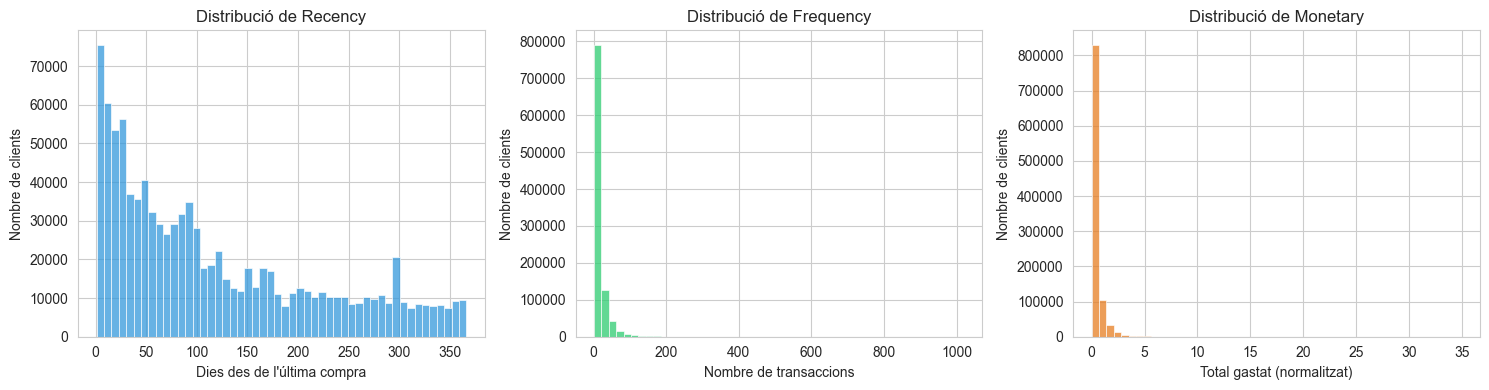

✓ Figura guardada a: outputs/fig_1_2_distribucions_RFM.png


In [54]:
# Tornem a fer els histogrames i els guardem com a fitxer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=50, ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title("Distribució de Recency")
axes[0].set_xlabel("Dies des de l'última compra")
axes[0].set_ylabel("Nombre de clients")

sns.histplot(rfm["Frequency"], bins=50, ax=axes[1], color="#2ecc71", edgecolor="white")
axes[1].set_title("Distribució de Frequency")
axes[1].set_xlabel("Nombre de transaccions")
axes[1].set_ylabel("Nombre de clients")

sns.histplot(rfm["Monetary"], bins=50, ax=axes[2], color="#e67e22", edgecolor="white")
axes[2].set_title("Distribució de Monetary")
axes[2].set_xlabel("Total gastat (normalitzat)")
axes[2].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.savefig("../outputs/fig_1_2_distribucions_RFM.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figura guardada a: outputs/fig_1_2_distribucions_RFM.png")

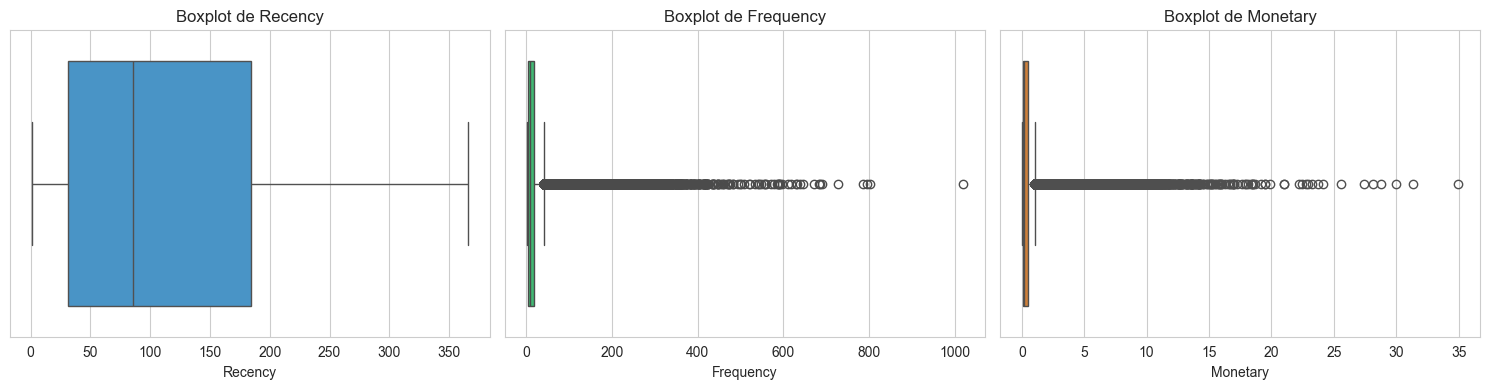

✓ Figura guardada a: outputs/fig_1_3_boxplots_RFM.png


In [55]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=rfm["Recency"], ax=axes[0], color="#3498db")
axes[0].set_title("Boxplot de Recency")

sns.boxplot(x=rfm["Frequency"], ax=axes[1], color="#2ecc71")
axes[1].set_title("Boxplot de Frequency")

sns.boxplot(x=rfm["Monetary"], ax=axes[2], color="#e67e22")
axes[2].set_title("Boxplot de Monetary")

plt.tight_layout()
plt.savefig("../outputs/fig_1_3_boxplots_RFM.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figura guardada a: outputs/fig_1_3_boxplots_RFM.png")

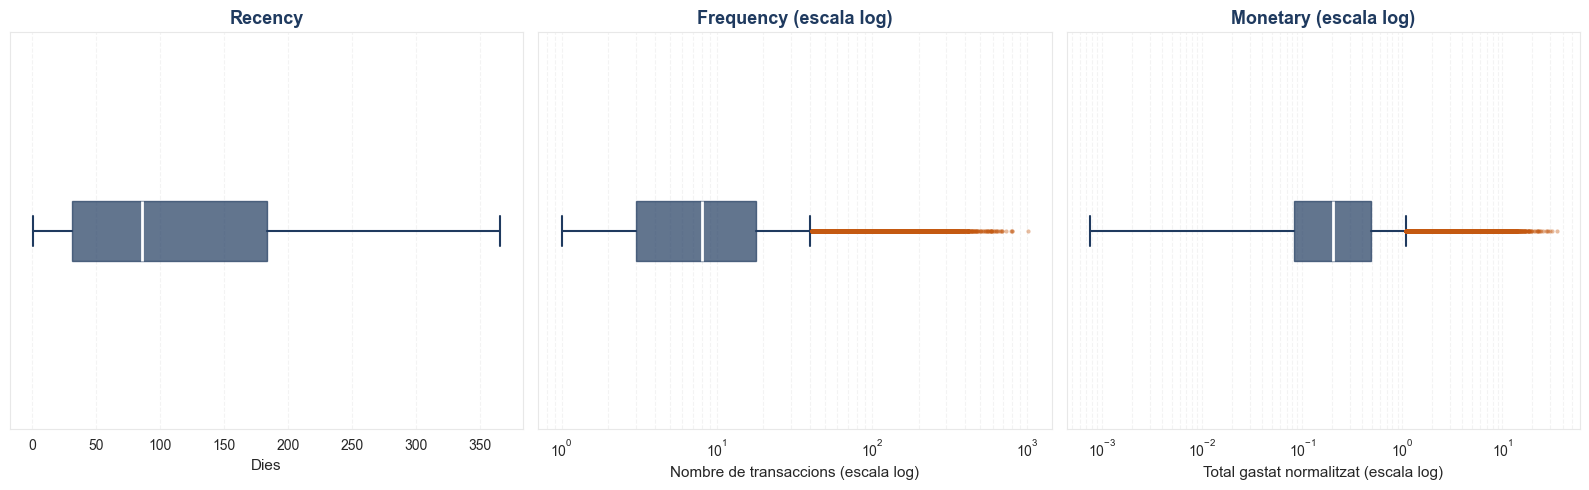

✅ Figura 1.3 regenerada amb escala log per a Frequency i Monetary.
📁 Guardada a: outputs/fig_1_3_boxplots_RFM.png


In [56]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CONFIGURACIÓ — Paleta Editorial del TFG
# ============================================
COLOR_PRIMARY = "#1F3A5F"      # Blau marí
COLOR_SECONDARY = "#4A6FA5"    # Blau metàl·lic
COLOR_ACCENT = "#C45911"       # Taronja terrós
COLOR_GRID = "#E8E8E8"         # Gris clar per a grid

# ============================================
# REGENERACIÓ DE LA FIGURA
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=0.3)

# Estil dels boxplots
boxprops = dict(facecolor=COLOR_PRIMARY, color=COLOR_PRIMARY, alpha=0.7)
whiskerprops = dict(color=COLOR_PRIMARY, linewidth=1.5)
capprops = dict(color=COLOR_PRIMARY, linewidth=1.5)
medianprops = dict(color="white", linewidth=2)
flierprops = dict(marker='o', markerfacecolor=COLOR_ACCENT,
                  markersize=3, markeredgecolor='none', alpha=0.4)

# ---------- Recency (ESCALA LINEAL — no canvia) ----------
ax = axes[0]
ax.boxplot(rfm['Recency'], vert=False, patch_artist=True,
           boxprops=boxprops, whiskerprops=whiskerprops,
           capprops=capprops, medianprops=medianprops, flierprops=flierprops)
ax.set_title('Recency', fontsize=13, fontweight='bold', color=COLOR_PRIMARY)
ax.set_xlabel('Dies', fontsize=11)
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.5, color=COLOR_GRID)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

# ---------- Frequency (ESCALA LOGARÍTMICA — NOVA) ----------
ax = axes[1]
ax.boxplot(rfm['Frequency'], vert=False, patch_artist=True,
           boxprops=boxprops, whiskerprops=whiskerprops,
           capprops=capprops, medianprops=medianprops, flierprops=flierprops)
ax.set_xscale('log')  # ← AIXÒ ÉS EL CANVI CLAU
ax.set_title('Frequency (escala log)', fontsize=13, fontweight='bold', color=COLOR_PRIMARY)
ax.set_xlabel('Nombre de transaccions (escala log)', fontsize=11)
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.5, color=COLOR_GRID, which='both')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

# ---------- Monetary (ESCALA LOGARÍTMICA — NOVA) ----------
ax = axes[2]
ax.boxplot(rfm['Monetary'], vert=False, patch_artist=True,
           boxprops=boxprops, whiskerprops=whiskerprops,
           capprops=capprops, medianprops=medianprops, flierprops=flierprops)
ax.set_xscale('log')  # ← AIXÒ ÉS EL CANVI CLAU
ax.set_title('Monetary (escala log)', fontsize=13, fontweight='bold', color=COLOR_PRIMARY)
ax.set_xlabel('Total gastat normalitzat (escala log)', fontsize=11)
ax.set_yticks([])
ax.grid(axis='x', linestyle='--', alpha=0.5, color=COLOR_GRID, which='both')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

# ============================================
# GUARDAR LA FIGURA
# ============================================
plt.tight_layout()
plt.savefig(r'C:\Users\User\OneDrive\Escritorio\4 uni\TFG_RFM_Hm\outputs\fig_1_3_boxplots_RFM.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Figura 1.3 regenerada amb escala log per a Frequency i Monetary.")
print("📁 Guardada a: outputs/fig_1_3_boxplots_RFM.png")

In [57]:
# Apliquem log(1+x) a les 3 variables RFM
rfm["Recency_log"]   = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"]  = np.log1p(rfm["Monetary"])

# Verifiquem el resultat
print("Estadístics després de la transformació log:")
rfm[["Recency_log", "Frequency_log", "Monetary_log"]].describe().round(3)

Estadístics després de la transformació log:


,Recency_log,Frequency_log,Monetary_log
count,994320.000,994320.000,994320.000
mean,4.240,2.222,0.292
std,1.211,1.013,0.308
min,0.693,0.693,0.001
25%,3.466,1.386,0.080
50%,4.466,2.197,0.184
75%,5.220,2.944,0.396
max,5.905,6.929,3.582


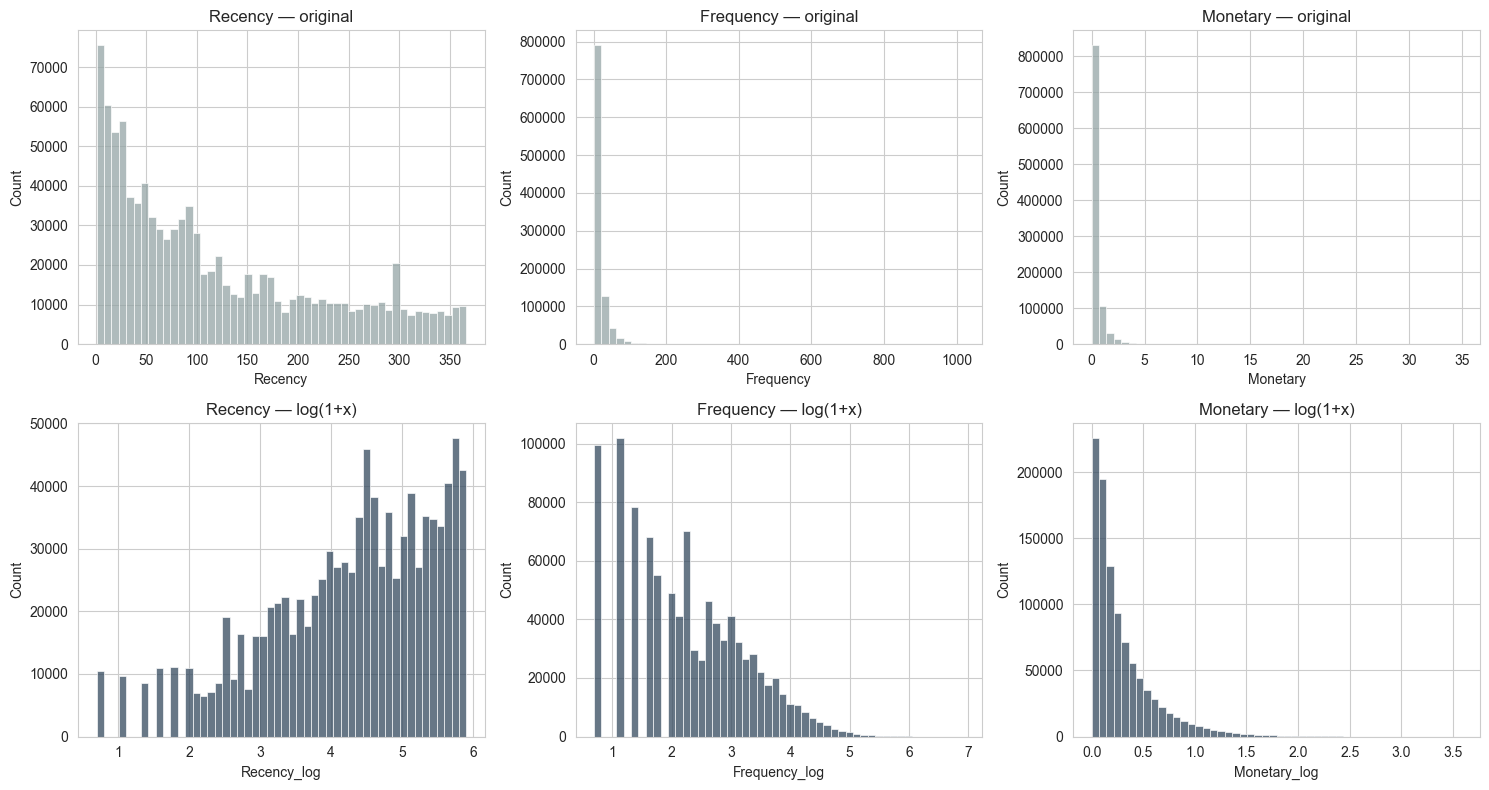

✓ Figura guardada a: outputs/fig_1_4_log_transform.png


In [58]:
# Figura 2x3: dalt = original, baix = log
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Fila 1: distribucions ORIGINALS
sns.histplot(rfm["Recency"],   bins=50, ax=axes[0,0], color="#95a5a6")
axes[0,0].set_title("Recency — original")

sns.histplot(rfm["Frequency"], bins=50, ax=axes[0,1], color="#95a5a6")
axes[0,1].set_title("Frequency — original")

sns.histplot(rfm["Monetary"],  bins=50, ax=axes[0,2], color="#95a5a6")
axes[0,2].set_title("Monetary — original")

# Fila 2: distribucions DESPRÉS DE log(1+x)
sns.histplot(rfm["Recency_log"],   bins=50, ax=axes[1,0], color="#34495e")
axes[1,0].set_title("Recency — log(1+x)")

sns.histplot(rfm["Frequency_log"], bins=50, ax=axes[1,1], color="#34495e")
axes[1,1].set_title("Frequency — log(1+x)")

sns.histplot(rfm["Monetary_log"],  bins=50, ax=axes[1,2], color="#34495e")
axes[1,2].set_title("Monetary — log(1+x)")

plt.tight_layout()
plt.savefig("../outputs/fig_1_4_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figura guardada a: outputs/fig_1_4_log_transform.png")

In [59]:
# Importem el StandardScaler de scikit-learn
from sklearn.preprocessing import StandardScaler

# Definim quines columnes volem estandarditzar
features = ["Recency_log", "Frequency_log", "Monetary_log"]

# Creem l'objecte scaler
scaler = StandardScaler()

# Apliquem la transformació
rfm[["Recency_z", "Frequency_z", "Monetary_z"]] = scaler.fit_transform(rfm[features])

# Verifiquem: cada variable hauria de tenir mitjana ≈ 0 i std ≈ 1
print("Després de l'estandardització:")
rfm[["Recency_z", "Frequency_z", "Monetary_z"]].describe().round(3)

Després de l'estandardització:


,Recency_z,Frequency_z,Monetary_z
count,994320.000,994320.000,994320.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-2.928,-1.509,-0.946
25%,-0.639,-0.825,-0.689
50%,0.187,-0.025,-0.351
75%,0.809,0.713,0.337
max,1.375,4.645,10.675


In [60]:
# Veiem totes les columnes que tenim ara
print("Columnes del DataFrame RFM final:")
print(rfm.columns.tolist())
print(f"\nForma: {rfm.shape}")
print("\nPrimeres 5 files:")
rfm.head()

Columnes del DataFrame RFM final:
['customer_id', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Recency_z', 'Frequency_z', 'Monetary_z']

Forma: (994320, 10)

Primeres 5 files:


,customer_id,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Recency_z,Frequency_z,Monetary_z
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,18,12,0.349136,2.944439,2.564949,0.299464,-1.069386,0.338110,0.023599
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,77,35,0.887542,4.356709,3.583519,0.635276,0.096429,1.343499,1.113137
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,8,14,0.559085,2.197225,2.708050,0.444099,-1.686204,0.479359,0.492866
3,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,42,9,0.359593,3.761200,2.302585,0.307186,-0.395157,0.079141,0.048651
4,000064249685c11552da43ef22a5030f35a147f723d5b0...,357,3,0.101644,5.880533,1.386294,0.096804,1.354332,-0.825293,-0.633932


In [61]:
# Guardem el RFM en 2 formats
rfm.to_csv("../outputs/rfm_clients.csv", index=False)
rfm.to_parquet("../outputs/rfm_clients.parquet", index=False)

print("✓ RFM guardat com a CSV i Parquet")
print(f"  Total de clients: {len(rfm):,}")

✓ RFM guardat com a CSV i Parquet
  Total de clients: 994,320


In [62]:
# Comprovació: quins DataFrames tinc a memòria?
print("Variables actuals al kernel:")
print("-" * 40)

# Comprovem cada variable possible
for nom in ["transactions", "tx", "rfm"]:
    if nom in dir():
        df = eval(nom)
        print(f"  ✅ {nom}: {df.shape}")
    else:
        print(f"  ❌ {nom}: NO existeix")

Variables actuals al kernel:
----------------------------------------
  ✅ transactions: (31788324, 5)
  ✅ tx: (14898423, 5)
  ✅ rfm: (994320, 10)


In [63]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

# ============================================
# FUNCIÓ HOPKINS
# ============================================
def hopkins_statistic(X, sample_size=10000):
    """Calcula l'índex de Hopkins."""
    X = np.asarray(X)
    n, d = X.shape
    sample_size = min(sample_size, n)
    
    # Punts uniformes dins el rang de X
    mins, maxs = X.min(axis=0), X.max(axis=0)
    X_uniform = np.random.uniform(mins, maxs, size=(sample_size, d))
    
    # Mostra aleatòria de X
    idx = np.random.choice(n, size=sample_size, replace=False)
    X_sample = X[idx]
    
    # Veïns més propers
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nbrs.kneighbors(X_uniform, n_neighbors=1)
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    
    u_sum = u_dist.sum()
    w_sum = w_dist[:, 1].sum()  # 2on veí (ignorem si mateix)
    
    return u_sum / (u_sum + w_sum)


# ============================================
# CÀLCUL DE L'ÍNDEX DE HOPKINS
# ============================================
X_rfm = rfm[['Recency_z', 'Frequency_z', 'Monetary_z']].values

print(f"Shape de l'input: {X_rfm.shape}")
print(f"Calculant l'índex de Hopkins (submostra de 10.000)...")
print()

H = hopkins_statistic(X_rfm, sample_size=10000)

print(f"{'='*60}")
print(f"  ÍNDEX DE HOPKINS = {H:.4f}")
print(f"{'='*60}")
print()

# Interpretació
if H < 0.6:
    print("⚠️  Dades aleatòries (NO clusteritzables)")
elif H < 0.75:
    print("🟡  Estructura moderada de clústers")
elif H < 0.9:
    print("🟢  Estructura clara de clústers")
else:
    print("✅  Estructura forta de clústers (IDEAL per K-means)")

Shape de l'input: (994320, 3)
Calculant l'índex de Hopkins (submostra de 10.000)...

  ÍNDEX DE HOPKINS = 0.9951

✅  Estructura forta de clústers (IDEAL per K-means)


In [64]:
# DIAGNÒSTIC: comprovar QUI és 'rfm' ARA MATEIX
print("ID de l'objecte rfm:", id(rfm))
print("Tipus:", type(rfm))
print("Shape:", rfm.shape)
print("Columnes ACTUALS:", rfm.columns.tolist())
print()
print("'Recency_z' a columnes?", 'Recency_z' in rfm.columns)

ID de l'objecte rfm: 2568803999584
Tipus: <class 'pandas.DataFrame'>
Shape: (994320, 10)
Columnes ACTUALS: ['customer_id', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Recency_z', 'Frequency_z', 'Monetary_z']

'Recency_z' a columnes? True


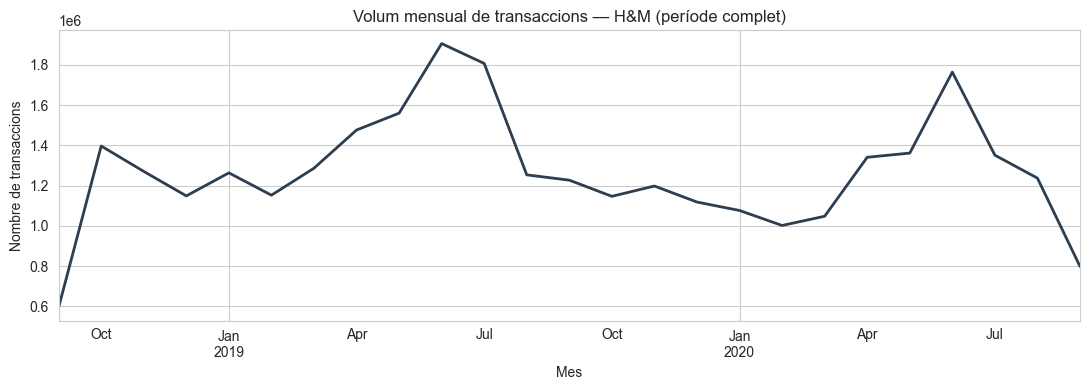

✓ Figura 1.1 guardada a outputs/fig_1_1_volum_mensual.png


In [65]:
# Figura 1.1: Volum mensual de transaccions (període complet)
tx_per_month = (
    transactions.set_index("t_dat")
    .resample("ME").size()
    .rename("n_transactions")
)

fig, ax = plt.subplots(figsize=(11, 4))
tx_per_month.plot(ax=ax, color="#2c3e50", linewidth=2)
ax.set_title("Volum mensual de transaccions — H&M (període complet)")
ax.set_xlabel("Mes")
ax.set_ylabel("Nombre de transaccions")
plt.tight_layout()

plt.savefig("../outputs/fig_1_1_volum_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Figura 1.1 guardada a outputs/fig_1_1_volum_mensual.png")

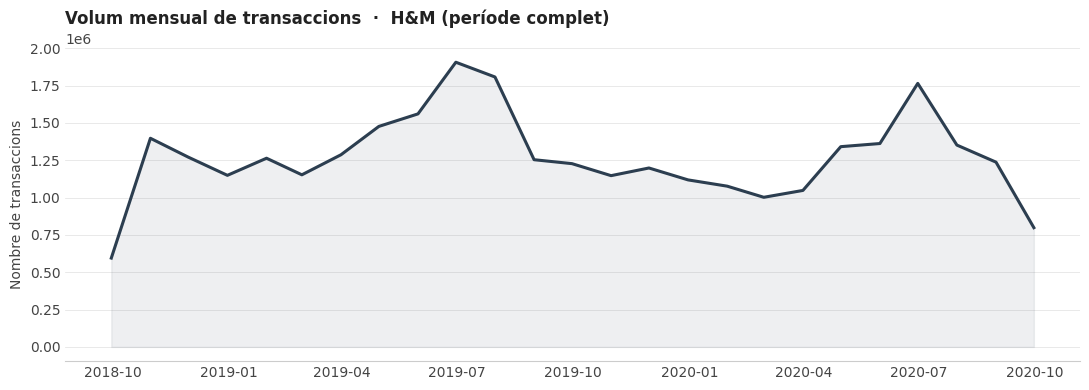

✓ Figura 1.1 regenerada


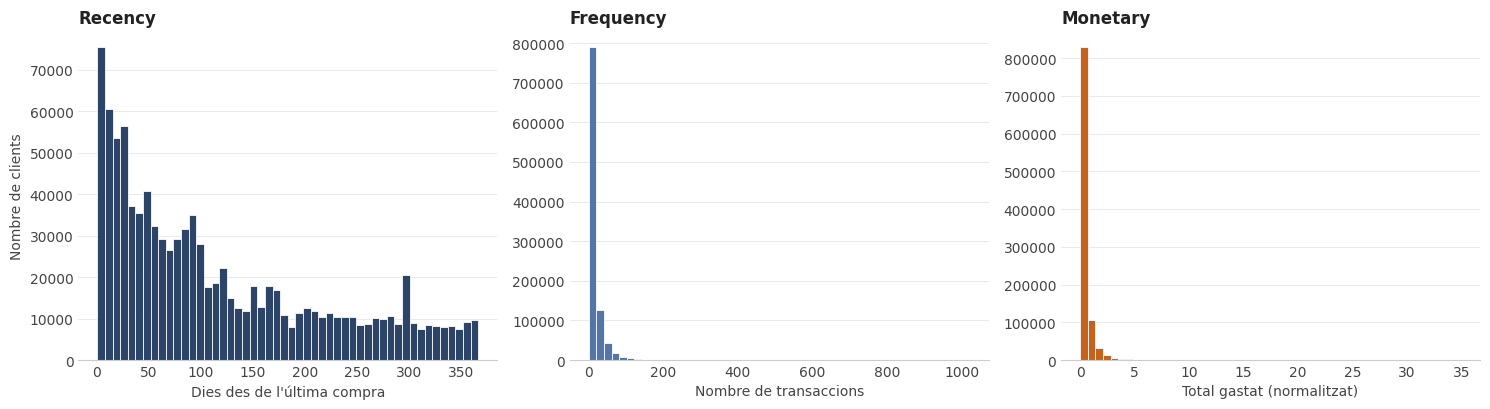

✓ Figura 1.2 regenerada


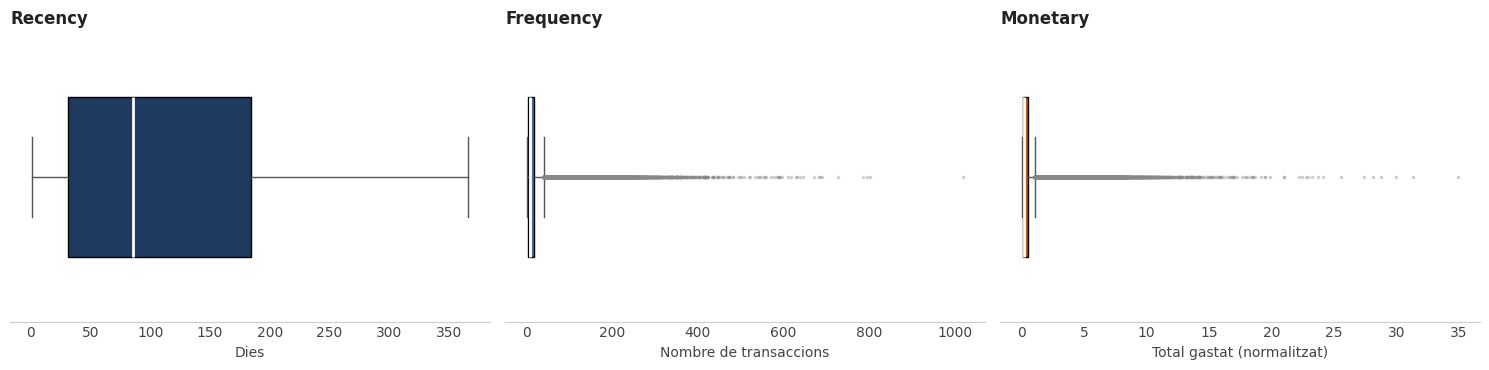

✓ Figura 1.3 regenerada


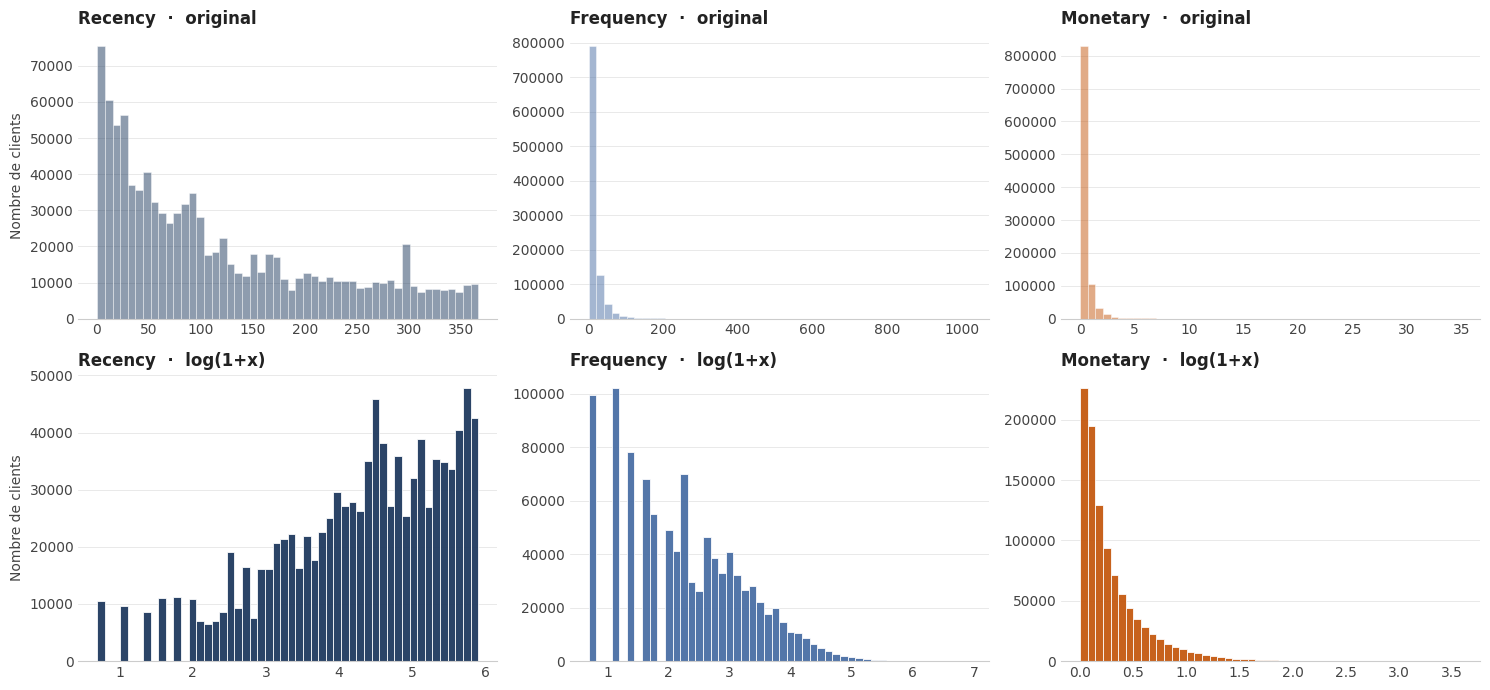

✓ Figura 1.4 regenerada

🎨 Totes les figures del Capítol I s'han regenerat amb l'estil Editorial.
📁 Ubicació: outputs/


In [66]:
# ====================================================================
# REGENERACIÓ DE FIGURES DEL CAPÍTOL I — ESTIL EDITORIAL
# ====================================================================
# Aquesta cel·la regenera totes les figures amb un estil coherent.
# Requereix: transactions, tx, rfm carregats a memòria.

import matplotlib.pyplot as plt

# --- Aplicar l'estil Editorial globalment ---------------------------
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

# Paleta editorial: blau marí, blau metàl·lic, taronja terrós
COL_R = "#1F3A5F"   # Recency
COL_F = "#4A6FA5"   # Frequency
COL_M = "#C45911"   # Monetary
COL_NEUTRE = "#2C3E50"  # Per a la sèrie temporal

def aplicar_estil_eixos(ax, ylab=None):
    """Aplica l'estil editorial als eixos d'un subgràfic."""
    ax.tick_params(axis="both", colors="#444", length=0)
    ax.yaxis.grid(True, color="#cccccc", linestyle="-", linewidth=0.5, alpha=0.6)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color("#cccccc")
    if ylab:
        ax.set_ylabel(ylab, color="#444")


# ====================================================================
# FIGURA 1.1 — Volum mensual de transaccions
# ====================================================================
tx_per_month = (
    transactions.set_index("t_dat")
    .resample("ME").size()
    .rename("n_transactions")
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tx_per_month.index, tx_per_month.values, color=COL_NEUTRE, linewidth=2.2)
ax.fill_between(tx_per_month.index, tx_per_month.values, alpha=0.08, color=COL_NEUTRE)
ax.set_title("Volum mensual de transaccions  ·  H&M (període complet)",
             loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(ax, ylab="Nombre de transaccions")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../outputs/fig_1_1_volum_mensual.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Figura 1.1 regenerada")


# ====================================================================
# FIGURA 1.2 — Histogrames RFM
# ====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(rfm["Recency"], bins=50, color=COL_R, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[0].set_title("Recency", loc="left", fontweight="bold", color="#222")
axes[0].set_xlabel("Dies des de l'última compra", color="#444")
aplicar_estil_eixos(axes[0], ylab="Nombre de clients")

axes[1].hist(rfm["Frequency"], bins=50, color=COL_F, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[1].set_title("Frequency", loc="left", fontweight="bold", color="#222")
axes[1].set_xlabel("Nombre de transaccions", color="#444")
aplicar_estil_eixos(axes[1])

axes[2].hist(rfm["Monetary"], bins=50, color=COL_M, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[2].set_title("Monetary", loc="left", fontweight="bold", color="#222")
axes[2].set_xlabel("Total gastat (normalitzat)", color="#444")
aplicar_estil_eixos(axes[2])

plt.tight_layout()
plt.savefig("../outputs/fig_1_2_distribucions_RFM.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Figura 1.2 regenerada")


# ====================================================================
# FIGURA 1.3 — Boxplots RFM
# ====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

box_props = dict(
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=2.5, markerfacecolor="#888",
                    markeredgecolor="none", alpha=0.4),
    whiskerprops=dict(color="#555"),
    capprops=dict(color="#555"),
)

bp1 = axes[0].boxplot(rfm["Recency"], vert=False, widths=0.55, **box_props)
bp1["boxes"][0].set_facecolor(COL_R)
axes[0].set_title("Recency", loc="left", fontweight="bold", color="#222")
axes[0].set_xlabel("Dies", color="#444")
aplicar_estil_eixos(axes[0])
axes[0].set_yticks([])

bp2 = axes[1].boxplot(rfm["Frequency"], vert=False, widths=0.55, **box_props)
bp2["boxes"][0].set_facecolor(COL_F)
axes[1].set_title("Frequency", loc="left", fontweight="bold", color="#222")
axes[1].set_xlabel("Nombre de transaccions", color="#444")
aplicar_estil_eixos(axes[1])
axes[1].set_yticks([])

bp3 = axes[2].boxplot(rfm["Monetary"], vert=False, widths=0.55, **box_props)
bp3["boxes"][0].set_facecolor(COL_M)
axes[2].set_title("Monetary", loc="left", fontweight="bold", color="#222")
axes[2].set_xlabel("Total gastat (normalitzat)", color="#444")
aplicar_estil_eixos(axes[2])
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig("../outputs/fig_1_3_boxplots_RFM.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Figura 1.3 regenerada")


# ====================================================================
# FIGURA 1.4 — Comparativa abans/després log
# ====================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

# Fila 1: ORIGINALS
axes[0,0].hist(rfm["Recency"], bins=50, color=COL_R, edgecolor="white", linewidth=0.6, alpha=0.5)
axes[0,0].set_title("Recency  ·  original", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[0,0], ylab="Nombre de clients")

axes[0,1].hist(rfm["Frequency"], bins=50, color=COL_F, edgecolor="white", linewidth=0.6, alpha=0.5)
axes[0,1].set_title("Frequency  ·  original", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[0,1])

axes[0,2].hist(rfm["Monetary"], bins=50, color=COL_M, edgecolor="white", linewidth=0.6, alpha=0.5)
axes[0,2].set_title("Monetary  ·  original", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[0,2])

# Fila 2: DESPRÉS DE log(1+x)
axes[1,0].hist(rfm["Recency_log"], bins=50, color=COL_R, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[1,0].set_title("Recency  ·  log(1+x)", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[1,0], ylab="Nombre de clients")

axes[1,1].hist(rfm["Frequency_log"], bins=50, color=COL_F, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[1,1].set_title("Frequency  ·  log(1+x)", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[1,1])

axes[1,2].hist(rfm["Monetary_log"], bins=50, color=COL_M, edgecolor="white", linewidth=0.6, alpha=0.95)
axes[1,2].set_title("Monetary  ·  log(1+x)", loc="left", fontweight="bold", color="#222")
aplicar_estil_eixos(axes[1,2])

plt.tight_layout()
plt.savefig("../outputs/fig_1_4_log_transform.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Figura 1.4 regenerada")

print("\n🎨 Totes les figures del Capítol I s'han regenerat amb l'estil Editorial.")
print("📁 Ubicació: outputs/")